In [1]:
%matplotlib inline


# Using Statsbomb
Getting familiar with Statsbomb data


In [2]:
#importing SBopen class from mplsoccer to open the data
from mplsoccer import Sbopen
# The first thing we have to do is open the data. We use a parser SBopen available in mplsoccer.
parser = Sbopen()

## Competition data
Using method *competition* of the parser we can explore competitions to find the competition we are interested in.
The most important information for us is in the *competition_id* (id of competition) and *season_id*.
The first one is the key in Statsbomb database of a competition, the second one of a season 
of this competition (for example WC 2018 would have a different *season_id* than WC 2014, but the same *competition_id*).



In [3]:
#opening data using competition method
df_competition = parser.competition()
#structure of data
df_competition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   competition_id             75 non-null     int64 
 1   season_id                  75 non-null     int64 
 2   country_name               75 non-null     object
 3   competition_name           75 non-null     object
 4   competition_gender         75 non-null     object
 5   competition_youth          75 non-null     bool  
 6   competition_international  75 non-null     bool  
 7   season_name                75 non-null     object
 8   match_updated              75 non-null     object
 9   match_updated_360          57 non-null     object
 10  match_available_360        11 non-null     object
 11  match_available            75 non-null     object
dtypes: bool(2), int64(2), object(8)
memory usage: 6.1+ KB


## Match data
Using method *match* of the parser we can explore matches of a competition to find the match we are interested in.
To open it we need to know the *competition_id* (id of competition) and *season_id*.
We know that for Women World Cup *competition_id* is 72 and *season_id* is 30
From this dataframe for us the most important imformation is provided in *match_id*, 
*home_team_id* and *home_team_name* and adequately *away_team_id* and *away_team_name*.



In [4]:
#opening data using match method
df_match = parser.match(competition_id=72, season_id=30)
#structure of data
df_match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   match_id                         52 non-null     int64         
 1   match_date                       52 non-null     datetime64[ns]
 2   kick_off                         52 non-null     datetime64[ns]
 3   home_score                       52 non-null     int64         
 4   away_score                       52 non-null     int64         
 5   match_status                     52 non-null     object        
 6   match_status_360                 52 non-null     object        
 7   last_updated                     52 non-null     datetime64[ns]
 8   last_updated_360                 52 non-null     datetime64[ns]
 9   match_week                       52 non-null     int64         
 10  competition_id                   52 non-null     int64         


## Lineup data
To check the lineups we use the *lineup* method. We do it for England Sweden WWC 2019 game - *game_id* is 69301 
- you can check that in the df_match. In this dataframe you will find all players who played in this game, their teams 
and jersey numbers
COMMENTED OUT BECAUSE OF CHANGE OF DATA FORMAT.



In [5]:
#opening data using match method
#df_lineup = parser.lineup(69301)
#structure of data
#df_lineup.info()

## Event data
The Statsbomb data that we will use the most during the course is event data. 
Knowing *game_id* you can open all the events that occured on the pitch
In the event dataframe you will find events with additional information, we will mostly use this dataframe.
Tactics dataframe provides information about player position on the pitch. 'Related' dataframe provides information
on events that were related to each other - for example ball pass and pressure applied. *df_freeze* consists of freezed
frames with player position in the moment of shots. We will learn more about tracking data later in the course.
Below, an example of event data is presented.



In [6]:
#opening data
df_event, df_related, df_freeze, df_tactics = parser.event(69301)
#if you want only event data you can use 
#df_event = parser.event(69301)[0]
#structure of data
df_event.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3289 entries, 0 to 3288
Data columns (total 73 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              3289 non-null   object 
 1   index                           3289 non-null   int64  
 2   period                          3289 non-null   int64  
 3   timestamp                       3289 non-null   object 
 4   minute                          3289 non-null   int64  
 5   second                          3289 non-null   int64  
 6   possession                      3289 non-null   int64  
 7   duration                        2457 non-null   float64
 8   match_id                        3289 non-null   int64  
 9   type_id                         3289 non-null   int64  
 10  type_name                       3289 non-null   object 
 11  possession_team_id              3289 non-null   int64  
 12  possession_team_name            32

## 360 data
Statsbomb offers 360 data which track not only location of an event but also players' location. To open them we need
an id of game. Later, we will also need id of the event. In the *df_frame* we find information on players' position (but only if teammate, not all information)
and in *df_visible* it is provided which part of the pitch was tracked during an event.



In [7]:
df_frame, df_visible = parser.frame(3788741)

# exploring the data
df_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45737 entries, 0 to 45736
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   teammate  45737 non-null  bool   
 1   actor     45737 non-null  bool   
 2   keeper    45737 non-null  bool   
 3   match_id  45737 non-null  int64  
 4   id        45737 non-null  object 
 5   x         45737 non-null  float64
 6   y         45737 non-null  float64
dtypes: bool(3), float64(2), int64(1), object(1)
memory usage: 1.5+ MB


## Before you start
Run these lines in Spyder/Jupyter notebook and explore dataframes 
to get more familiar before you start working on the course.


In [8]:
# 1) See what columns you have and a quick preview
print("Columns:", df_competition.columns.tolist())
display(df_competition.head())

Columns: ['competition_id', 'season_id', 'country_name', 'competition_name', 'competition_gender', 'competition_youth', 'competition_international', 'season_name', 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


In [9]:
# --- List all unique competition names in the dataset ---
if "competition_name" in df_competition.columns:
    comp_names = (
        df_competition["competition_name"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )
    comp_names = sorted(comp_names)
    print(f"Total competitions: {len(comp_names)}")
    for c in comp_names:
        print("-", c)
else:
    print("No 'competition_name' column found in df_competition. Check df_competition.columns to confirm.")


Total competitions: 21
- 1. Bundesliga
- African Cup of Nations
- Champions League
- Copa America
- Copa del Rey
- FA Women's Super League
- FIFA U20 World Cup
- FIFA World Cup
- Indian Super league
- La Liga
- Liga Profesional
- Ligue 1
- Major League Soccer
- NWSL
- North American League
- Premier League
- Serie A
- UEFA Euro
- UEFA Europa League
- UEFA Women's Euro
- Women's World Cup


In [10]:
# Filter for the "UEFA Euro" competition
df_euro = (
    df_competition.loc[df_competition["competition_name"] == "UEFA Euro",
                       ["competition_id","competition_name","season_id","season_name","country_name"]]
    .drop_duplicates()
    .sort_values("season_name")
)

print("UEFA Euro competitions available:")
display(df_euro)

UEFA Euro competitions available:


,competition_id,competition_name,season_id,season_name,country_name
69,55,UEFA Euro,43,2020,Europe
68,55,UEFA Euro,282,2024,Europe


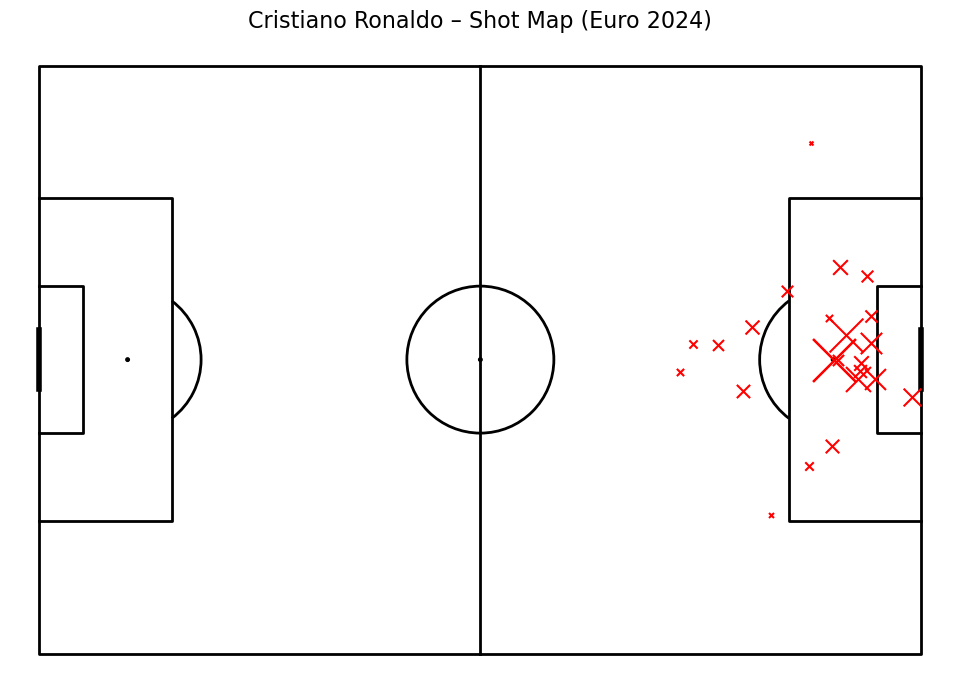

In [12]:
import pandas as pd

from mplsoccer import Pitch
import matplotlib.pyplot as plt
import numpy as np

def get_shot_outcome(row):
    # Try multiple possibilities for shot outcome
    if "shot_outcome_name" in row:
        return row["shot_outcome_name"]
    if "shot_outcome" in row:
        return row["shot_outcome"]
    if "shot.outcome.name" in row:
        return row["shot.outcome.name"]
    return None

# Get Portugal matches
df_match = parser.match(competition_id=55, season_id=282)
match_ids = df_match[(df_match['home_team_name']=='Portugal') | (df_match['away_team_name']=='Portugal')]['match_id'].tolist()

ronaldo_shots = []

for mid in match_ids:
    df_event = parser.event(mid)[0]
    # Filter Ronaldo shots
    mask = (df_event['type_name']=='Shot') & (df_event['player_name'].str.contains("Ronaldo", case=False, na=False))
    shots = df_event.loc[mask].copy()
    if not shots.empty:
        shots["outcome"] = shots.apply(get_shot_outcome, axis=1)
        ronaldo_shots.append(shots)

ronaldo_shots = pd.concat(ronaldo_shots, ignore_index=True) if ronaldo_shots else pd.DataFrame()

# --- Plot shot map ---
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))

for _, row in ronaldo_shots.iterrows():
    x, y = row['x'], row['y']
    size = 1200 * row.get('shot_statsbomb_xg', 0.05)  # safe fallback
    if row['outcome'] == 'Goal':
        pitch.scatter(x, y, s=size, c='green', marker='o', edgecolors='black', ax=ax, zorder=3)
    else:
        pitch.scatter(x, y, s=size, c='red', marker='x', ax=ax, zorder=3)

ax.set_title("Cristiano Ronaldo – Shot Map (Euro 2024)", fontsize=16)
plt.show()


In [14]:
def get_portugal_players(competition_id, season_id):
    # Get matches for that competition/season
    df_match = parser.match(competition_id=competition_id, season_id=season_id)
    # Filter Portugal matches
    pt_matches = df_match[(df_match['home_team_name']=='Portugal') | 
                          (df_match['away_team_name']=='Portugal')]

    players = set()

    for mid in pt_matches['match_id']:
        # parser.lineup(mid) returns a DataFrame in your version
        df_lineup = parser.lineup(mid)
        df_team = df_lineup[df_lineup['team_name']=='Portugal']
        players.update(df_team['player_name'].dropna().tolist())

    return sorted(players)

# Euro 2020 IDs
players_2020 = get_portugal_players(competition_id=55, season_id=43)

# Euro 2024 IDs
players_2024 = get_portugal_players(competition_id=55, season_id=282)

print("🇵🇹 Portugal squad Euro 2020:")
print(players_2020)

print("\n🇵🇹 Portugal squad Euro 2024:")
print(players_2024)


🇵🇹 Portugal squad Euro 2020:
['André Miguel Valente Silva', 'Anthony Lopes', 'Bernardo Mota Veiga de Carvalho e Silva', 'Bruno Miguel Borges Fernandes', 'Cristiano Ronaldo dos Santos Aveiro', 'Danilo Luís Hélio Pereira', 'Diogo José Teixeira da Silva', 'Gonçalo Manuel Ganchinho Guedes', 'José Diogo Dalot Teixeira', 'José Miguel da Rocha Fonte', 'João Filipe Iria Santos Moutinho', 'João Félix Sequeira', 'João Maria Lobo Alves Palhinha Gonçalves', 'Kléper Laveran Lima Ferreira', 'Nuno Mendes', 'Nélson Cabral Semedo', 'Pedro António Pereira Gonçalves', 'Rafael Alexandre Fernandes Ferreira da Silva', 'Raphaël Adelino José Guerreiro', 'Renato Júnior Luz Sanches', 'Rui Pedro dos Santos Patrício', 'Rui Tiago Dantas da Silva', 'Rúben Diogo Da Silva Neves', 'Rúben Santos Gato Alves Dias', 'Sérgio Miguel Relvas de Oliveira', 'William Silva de Carvalho']

🇵🇹 Portugal squad Euro 2024:
['António João Pereira Albuquerque Tavares Silva', 'Bernardo Mota Veiga de Carvalho e Silva', 'Bruno Miguel Borges

In [28]:
# === EURO 2024 DATA PIPELINE (Ronaldo vs Ramos/Jota/Félix) ===
# Requirements: you have `parser = Sbopen()` ready.

import pandas as pd
import numpy as np

COMP_ID = 55     # UEFA Euro
SEASON_ID = 282  # 2024
TEAM = "Portugal"

# ---- Robust helpers ---------------------------------------------------------

def get_outcome_val(row):
    """Return shot outcome string robustly across flattened schemas."""
    if isinstance(row, pd.Series):
        if "shot_outcome_name" in row: return row["shot_outcome_name"]
        if "shot_outcome" in row:      return row["shot_outcome"]
        if "shot.outcome.name" in row: return row["shot.outcome.name"]
    return None

def event_df(match_id):
    """Convenience wrapper to fetch events DF from Sbopen."""
    # parser.event returns (df_event, df_related, df_freeze, df_tactics)
    return parser.event(int(match_id))[0]

def get_portugal_match_ids():
    df_match = parser.match(COMP_ID, SEASON_ID)
    mask = (df_match['home_team_name'] == TEAM) | (df_match['away_team_name'] == TEAM)
    return df_match.loc[mask, 'match_id'].astype(int).tolist(), df_match

def minutes_heuristic(df_ev):
    """
    Very simple minutes estimate per player in one match:
    - assume 90 for every starter
    - if there's a Substitution event, set off-player = minute,
      and add (90 - minute) to replacement.
    Works with columns flattened by Sbopen (player_name, substitution_replacement_name).
    """
    out = {}
    type_col = "type_name"
    # starters: look for Starting XI rows and grab those names
    starters = set()
    if "type_name" in df_ev.columns:
        xi = df_ev[df_ev[type_col] == "Starting XI"]
        if not xi.empty and "tactics_lineup" in xi.columns:
            # Some Sbopen versions include a parsed 'tactics_lineup' (list of dicts)
            # If not present, fall back later to anyone with an event.
            for _, row in xi.iterrows():
                lineup = row.get("tactics_lineup", None)
                if isinstance(lineup, list):
                    for p in lineup:
                        name = (p.get("player", {}) or {}).get("name")
                        if name: starters.add(name)

    # fall back: anyone who had an event is assumed to have minutes (rough)
    if not starters:
        starters = set(df_ev["player_name"].dropna().astype(str).tolist())

    # initialize to 90
    for name in starters:
        out[name] = 90.0

    # apply subs if available
    subs = df_ev[df_ev[type_col] == "Substitution"] if type_col in df_ev.columns else pd.DataFrame()
    if not subs.empty:
        # off player is in 'player_name'; replacement name often in 'substitution_replacement_name'
        rep_col = "substitution_replacement_name" if "substitution_replacement_name" in subs.columns else None
        for _, row in subs.iterrows():
            minute = float(row.get("minute", 0))
            off_name = row.get("player_name", None)
            if off_name:
                out[off_name] = min(out.get(off_name, 90.0), minute)
            if rep_col:
                on_name = row.get(rep_col, None)
                if on_name:
                    out[on_name] = out.get(on_name, 0.0) + max(0.0, 90.0 - minute)

    return out  # dict: player_name -> minutes (approx)
def collect_tournament_shots_and_minutes(match_ids):
    """Return shots_df (all shots) and players_df (agg with minutes)."""
    shot_rows = []
    minutes_accum = {}

    for mid in match_ids:
        ev = event_df(mid)
        if ev.empty: 
            continue

        # minutes
        m = minutes_heuristic(ev)
        for name, mins in m.items():
            minutes_accum[name] = minutes_accum.get(name, 0.0) + mins

        # shots
        if "type_name" not in ev.columns: 
            continue
        shots = ev[ev["type_name"] == "Shot"].copy()
        if shots.empty: 
            continue

        # outcome — StatsBomb flatten here is just "outcome"
        if "outcome" in shots.columns:
            shots["outcome"] = shots["outcome"].astype(str)
        else:
            shots["outcome"] = None

        # x/y
        if not {"x","y"}.issubset(shots.columns) and "location" in shots.columns:
            shots["x"] = shots["location"].apply(lambda loc: loc[0] if isinstance(loc, (list,tuple)) and len(loc)>=2 else np.nan)
            shots["y"] = shots["location"].apply(lambda loc: loc[1] if isinstance(loc, (list,tuple)) and len(loc)>=2 else np.nan)

        # xG
        if "shot_statsbomb_xg" not in shots.columns:
            shots["shot_statsbomb_xg"] = shots.get("shot_xg", np.nan)

        keep_cols = ["match_id","team_name","player_name","x","y","shot_statsbomb_xg","outcome"]
        for c in keep_cols:
            if c not in shots.columns:
                shots[c] = np.nan
        shots["match_id"] = int(mid)

        shot_rows.append(shots[keep_cols])

    shots_df = pd.concat(shot_rows, ignore_index=True) if shot_rows else pd.DataFrame(columns=["match_id","team_name","player_name","x","y","shot_statsbomb_xg","outcome"])

    # per-player aggregates
    if not shots_df.empty:
        agg = (shots_df
               .groupby("player_name", dropna=False)
               .agg(shots=("x","count"),
                    goals=("outcome", lambda s: (s=="Goal").sum()),
                    xg=("shot_statsbomb_xg","sum"))
               .reset_index())
    else:
        agg = pd.DataFrame(columns=["player_name","shots","goals","xg"])

    # minutes
    agg["minutes"] = agg["player_name"].map(minutes_accum).fillna(0.0)

    # per-90
    with np.errstate(divide='ignore', invalid='ignore'):
        agg["shots_per90"] = np.where(agg["minutes"]>0, agg["shots"]*90/agg["minutes"], np.nan)
        agg["xg_per90"]    = np.where(agg["minutes"]>0, agg["xg"]*90/agg["minutes"], np.nan)
        agg["goals_per90"] = np.where(agg["minutes"]>0, agg["goals"]*90/agg["minutes"], np.nan)

    return shots_df, agg

# ---- Run the assembly -------------------------------------------------------

portugal_match_ids, df_match_all = get_portugal_match_ids()
shots_df_24, players_24 = collect_tournament_shots_and_minutes(df_match_all["match_id"].astype(int).tolist())

# Convenience list for our focus + comparators
focus = "Cristiano Ronaldo"                 # robust matching by contains
comparators = ["Gonçalo Ramos", "Diogo Jota", "João Félix"]

print("Ready. DataFrames created:")
print(" - shots_df_24:", shots_df_24.shape)
print(" - players_24 :", players_24.shape)


Ready. DataFrames created:
 - shots_df_24: (1340, 7)
 - players_24 : (337, 8)


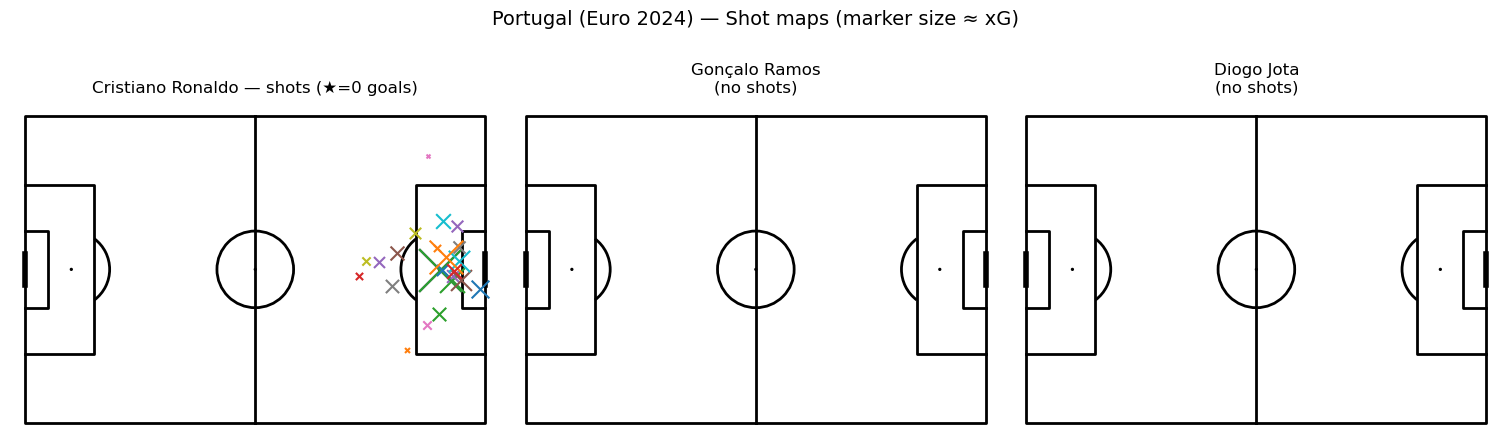

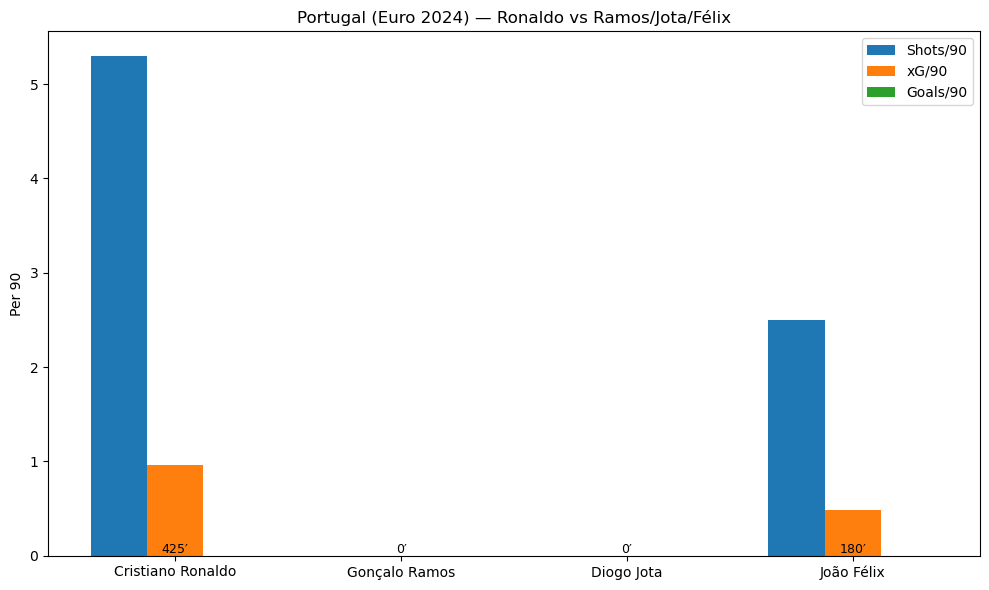

Comparison table (minutes + per-90):


,player,minutes,shots_per90,xg_per90,goals_per90
0,Cristiano Ronaldo,425.0,5.294118,0.960631,0.0
1,Gonçalo Ramos,0.0,NaN,NaN,NaN
2,Diogo Jota,0.0,NaN,NaN,NaN
3,João Félix,180.0,2.500000,0.482351,0.0


In [29]:
# === FIGURE 1: Shot maps (Ronaldo vs Ramos/Jota/Félix) ===
from mplsoccer import Pitch
import matplotlib.pyplot as plt

def name_contains(df, col, needle):
    return df[col].astype(str).str.contains(needle, case=False, na=False)

def plot_player_shotmap(ax, df, player_label):
    pitch = Pitch(pitch_type='statsbomb', line_color='black')
    pitch.draw(ax=ax)
    sdf = df[name_contains(df, "player_name", player_label) & name_contains(df, "team_name", TEAM)].copy()
    if sdf.empty:
        ax.set_title(f"{player_label}\n(no shots)", fontsize=12)
        return
    for _, r in sdf.iterrows():
        x, y = float(r.get("x", np.nan)), float(r.get("y", np.nan))
        if np.isnan(x) or np.isnan(y): 
            continue
        size = 1200 * float(r.get("shot_statsbomb_xg", 0.05))
        if str(r.get("outcome","")) == "Goal":
            pitch.scatter(x, y, s=size, marker='o', edgecolors='black', ax=ax, zorder=3)
        else:
            pitch.scatter(x, y, s=size, marker='x', ax=ax, zorder=3)
    goals = int((sdf["outcome"]=="Goal").sum())
    ax.set_title(f"{player_label} — shots (★={goals} goals)", fontsize=12)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
plot_player_shotmap(axes[0], shots_df_24, "Cristiano Ronaldo")
plot_player_shotmap(axes[1], shots_df_24, "Gonçalo Ramos")
plot_player_shotmap(axes[2], shots_df_24, "Diogo Jota")
fig.suptitle("Portugal (Euro 2024) — Shot maps (marker size ≈ xG)", fontsize=14)
plt.show()

# === FIGURE 2: Per-90 comparison (Ronaldo vs Ramos/Jota/Félix) ===
import numpy as np

def pick_players_table(players_df, names):
    out = []
    for n in names:
        m = players_df[name_contains(players_df, "player_name", n)].copy()
        if not m.empty:
            row = m.sort_values("minutes", ascending=False).iloc[0]  # take the heaviest-minute entry if duplicates
            out.append({
                "player": n,
                "minutes": float(row["minutes"]),
                "shots_per90": float(row["shots_per90"]),
                "xg_per90": float(row["xg_per90"]),
                "goals_per90": float(row["goals_per90"]),
            })
        else:
            out.append({"player": n, "minutes": 0.0, "shots_per90": np.nan, "xg_per90": np.nan, "goals_per90": np.nan})
    return pd.DataFrame(out)

compare_names = ["Cristiano Ronaldo", "Gonçalo Ramos", "Diogo Jota", "João Félix"]
tbl = pick_players_table(players_24, compare_names)

# Bar chart (grouped)
x = np.arange(len(tbl))
w = 0.25

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - w, tbl["shots_per90"],  w, label="Shots/90")
ax.bar(x,       tbl["xg_per90"],   w, label="xG/90")
ax.bar(x + w,   tbl["goals_per90"],w, label="Goals/90")
ax.set_xticks(x)
ax.set_xticklabels(tbl["player"], rotation=0)
ax.set_ylabel("Per 90")
ax.set_title("Portugal (Euro 2024) — Ronaldo vs Ramos/Jota/Félix")
ax.legend()
for i, m in enumerate(tbl["minutes"]):
    ax.text(i, 0, f"{m:.0f}′", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("Comparison table (minutes + per-90):")
display(tbl)


In [30]:
# === EURO 2020 DATA PIPELINE (Ronaldo vs André Silva / Jota / Félix / Guedes) ===

COMP_ID = 55     # UEFA Euro
SEASON_ID = 43   # 2020
TEAM = "Portugal"

portugal_match_ids_20, df_match_all_20 = (
    parser.match(COMP_ID, SEASON_ID)
    .pipe(lambda df: (
        df.loc[(df['home_team_name']==TEAM) | (df['away_team_name']==TEAM), 'match_id'].astype(int).tolist(),
        df
    ))
)

shots_df_20, players_20 = collect_tournament_shots_and_minutes(df_match_all_20["match_id"].astype(int).tolist())

print("Ready. DataFrames created for Euro 2020:")
print(" - shots_df_20:", shots_df_20.shape)
print(" - players_20 :", players_20.shape)


Ready. DataFrames created for Euro 2020:
 - shots_df_20: (1289, 7)
 - players_20 : (329, 8)


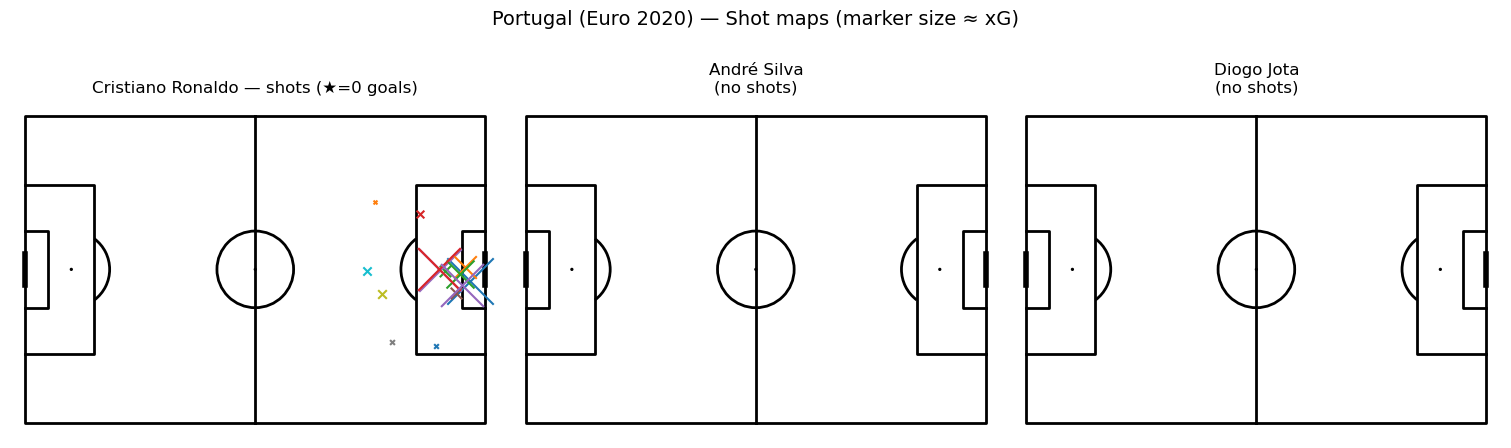

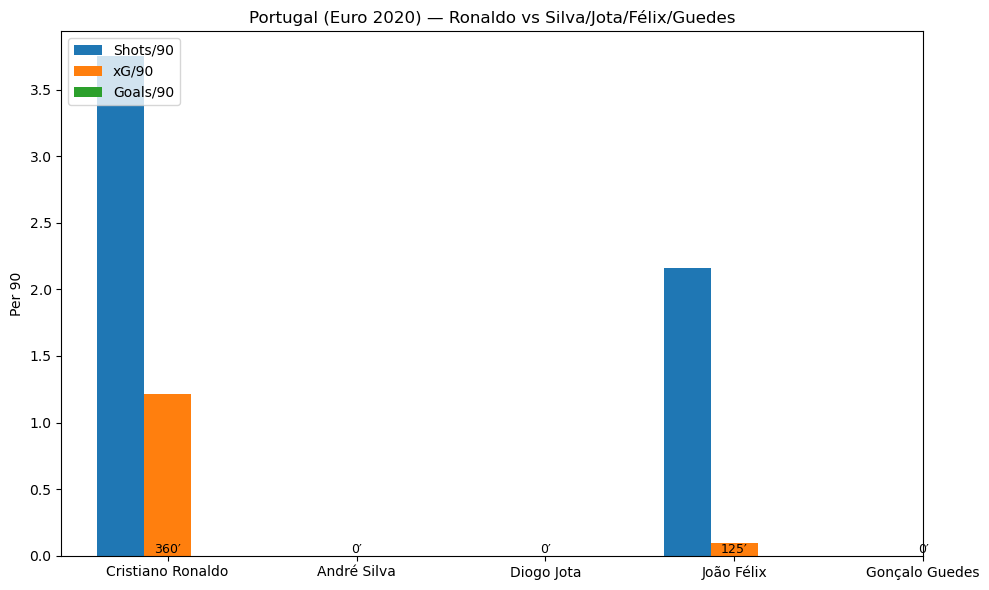

Euro 2020 comparison table:


,player,minutes,shots_per90,xg_per90,goals_per90
0,Cristiano Ronaldo,360.0,3.75,1.215944,0.0
1,André Silva,0.0,NaN,NaN,NaN
2,Diogo Jota,0.0,NaN,NaN,NaN
3,João Félix,125.0,2.16,0.095297,0.0
4,Gonçalo Guedes,0.0,NaN,NaN,NaN


In [31]:
# === FIGURE 1: Shot maps (Euro 2020) ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
plot_player_shotmap(axes[0], shots_df_20, "Cristiano Ronaldo")
plot_player_shotmap(axes[1], shots_df_20, "André Silva")
plot_player_shotmap(axes[2], shots_df_20, "Diogo Jota")
fig.suptitle("Portugal (Euro 2020) — Shot maps (marker size ≈ xG)", fontsize=14)
plt.show()

# === FIGURE 2: Per-90 comparison (Euro 2020) ===
compare_names_20 = ["Cristiano Ronaldo", "André Silva", "Diogo Jota", "João Félix", "Gonçalo Guedes"]
tbl_20 = pick_players_table(players_20, compare_names_20)

x = np.arange(len(tbl_20))
w = 0.25

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - w, tbl_20["shots_per90"],  w, label="Shots/90")
ax.bar(x,       tbl_20["xg_per90"],   w, label="xG/90")
ax.bar(x + w,   tbl_20["goals_per90"],w, label="Goals/90")
ax.set_xticks(x)
ax.set_xticklabels(tbl_20["player"], rotation=0)
ax.set_ylabel("Per 90")
ax.set_title("Portugal (Euro 2020) — Ronaldo vs Silva/Jota/Félix/Guedes")
ax.legend()
for i, m in enumerate(tbl_20["minutes"]):
    ax.text(i, 0, f"{m:.0f}′", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("Euro 2020 comparison table:")
display(tbl_20)


Ronaldo vs felix


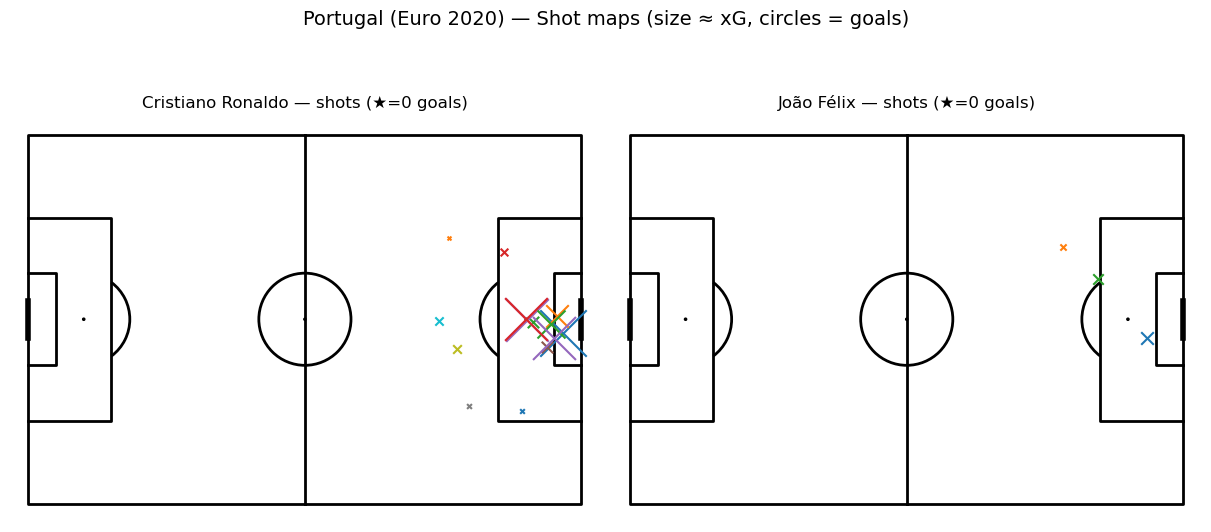

In [32]:
# === EURO 2020: Ronaldo vs Félix shot maps ===

COMP_ID = 55     # UEFA Euro
SEASON_ID = 43   # 2020
TEAM = "Portugal"

# Collect data
df_match_20 = parser.match(COMP_ID, SEASON_ID)
match_ids_20 = df_match_20[(df_match_20['home_team_name']==TEAM) | (df_match_20['away_team_name']==TEAM)]['match_id'].astype(int).tolist()
shots_df_20, _ = collect_tournament_shots_and_minutes(match_ids_20)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
plot_player_shotmap(axes[0], shots_df_20, "Cristiano Ronaldo")
plot_player_shotmap(axes[1], shots_df_20, "João Félix")
fig.suptitle("Portugal (Euro 2020) — Shot maps (size ≈ xG, circles = goals)", fontsize=14)
plt.show()


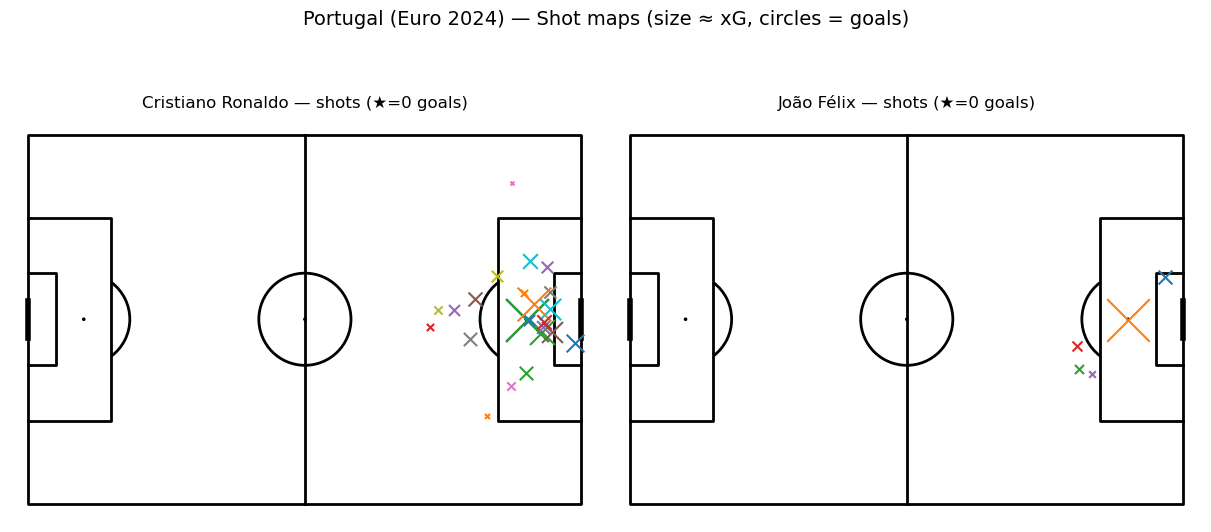

In [33]:
# === EURO 2024: Ronaldo vs Félix shot maps ===

COMP_ID = 55     # UEFA Euro
SEASON_ID = 282  # 2024
TEAM = "Portugal"

# Collect data
df_match_24 = parser.match(COMP_ID, SEASON_ID)
match_ids_24 = df_match_24[(df_match_24['home_team_name']==TEAM) | (df_match_24['away_team_name']==TEAM)]['match_id'].astype(int).tolist()
shots_df_24, _ = collect_tournament_shots_and_minutes(match_ids_24)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
plot_player_shotmap(axes[0], shots_df_24, "Cristiano Ronaldo")
plot_player_shotmap(axes[1], shots_df_24, "João Félix")
fig.suptitle("Portugal (Euro 2024) — Shot maps (size ≈ xG, circles = goals)", fontsize=14)
plt.show()


In [34]:
# === Ronaldo vs Félix per-90 stats across Euro 2020 and 2024 ===

def player_stats(players_df, player_label, season_label):
    """Extract per-90 stats for one player (or NaN if missing)."""
    mask = players_df["player_name"].astype(str).str.contains(player_label, case=False, na=False)
    if not mask.any():
        return {"player": player_label, "season": season_label,
                "minutes": 0, "shots_per90": np.nan, "xg_per90": np.nan, "goals_per90": np.nan}
    row = players_df.loc[mask].sort_values("minutes", ascending=False).iloc[0]
    return {"player": player_label, "season": season_label,
            "minutes": float(row["minutes"]),
            "shots_per90": float(row["shots_per90"]),
            "xg_per90": float(row["xg_per90"]),
            "goals_per90": float(row["goals_per90"])}

# Euro 2020 data
df_match_20 = parser.match(55, 43)
match_ids_20 = df_match_20[(df_match_20['home_team_name']=='Portugal') | (df_match_20['away_team_name']=='Portugal')]['match_id'].astype(int).tolist()
shots_df_20, players_20 = collect_tournament_shots_and_minutes(match_ids_20)

# Euro 2024 data
df_match_24 = parser.match(55, 282)
match_ids_24 = df_match_24[(df_match_24['home_team_name']=='Portugal') | (df_match_24['away_team_name']=='Portugal')]['match_id'].astype(int).tolist()
shots_df_24, players_24 = collect_tournament_shots_and_minutes(match_ids_24)

# Build table
records = []
for season, players_df in [("Euro 2020", players_20), ("Euro 2024", players_24)]:
    for pl in ["Cristiano Ronaldo", "João Félix"]:
        records.append(player_stats(players_df, pl, season))

ron_felix_table = pd.DataFrame(records)
display(ron_felix_table)


,player,season,minutes,shots_per90,xg_per90,goals_per90
0,Cristiano Ronaldo,Euro 2020,360.0,3.750000,1.215944,0.0
1,João Félix,Euro 2020,125.0,2.160000,0.095297,0.0
2,Cristiano Ronaldo,Euro 2024,425.0,5.294118,0.960631,0.0
3,João Félix,Euro 2024,180.0,2.500000,0.482351,0.0


In [35]:
print("Euro 2020 shot columns:", shots_df_20.columns.tolist())
print("Euro 24 shot columns:", shots_df_24.columns.tolist())

print("Unique values in shot_outcome (if exists):")
if "shot_outcome" in shots_df_20.columns:
    print(shots_df_20["shot_outcome"].unique())
if "shot.outcome.name" in shots_df_20.columns:
    print(shots_df_20["shot.outcome.name"].unique())
if "shot_outcome_name" in shots_df_20.columns:
    print(shots_df_20["shot_outcome_name"].unique())


Euro 2020 shot columns: ['match_id', 'team_name', 'player_name', 'x', 'y', 'shot_statsbomb_xg', 'outcome']
Euro 24 shot columns: ['match_id', 'team_name', 'player_name', 'x', 'y', 'shot_statsbomb_xg', 'outcome']
Unique values in shot_outcome (if exists):


In [36]:
import pandas as pd
import numpy as np
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# --- Helpers ---
def event_df(match_id):
    """Fetch events DataFrame for one match."""
    return parser.event(int(match_id))[0]

def normalize_outcome(val):
    """Ensure shot outcome is returned as a string like 'Goal'."""
    if isinstance(val, dict):
        return val.get("name")
    if pd.isna(val):
        return None
    return str(val)

def minutes_heuristic(df_ev):
    """Approximate minutes played per player."""
    out = {}
    if "type_name" in df_ev.columns:
        # assume starters play 90
        starters = set(df_ev[df_ev["type_name"]=="Starting XI"]["player_name"].dropna())
        for s in starters:
            out[s] = 90.0
        # subs
        subs = df_ev[df_ev["type_name"]=="Substitution"]
        if not subs.empty:
            for _, row in subs.iterrows():
                minute = float(row.get("minute", 0))
                off = row.get("player_name")
                on = row.get("substitution_replacement_name")
                if off:
                    out[off] = min(out.get(off, 90.0), minute)
                if on:
                    out[on] = out.get(on, 0.0) + max(0.0, 90.0 - minute)
    return out

def collect_tournament_shots_and_minutes(match_ids):
    """Return (shots_df, players_df) for all matches in a tournament."""
    shot_rows = []
    minutes_accum = {}

    for mid in match_ids:
        ev = event_df(mid)
        if ev.empty: 
            continue

        # minutes
        m = minutes_heuristic(ev)
        for name, mins in m.items():
            minutes_accum[name] = minutes_accum.get(name, 0.0) + mins

        # shots
        shots = ev[ev["type_name"]=="Shot"].copy()
        if shots.empty:
            continue

        # normalize outcome
        shots["outcome"] = shots["outcome"].apply(normalize_outcome) if "outcome" in shots.columns else None

        # x/y coordinates
        if "x" not in shots.columns or "y" not in shots.columns:
            if "location" in shots.columns:
                shots["x"] = shots["location"].apply(lambda loc: loc[0] if isinstance(loc,(list,tuple)) else np.nan)
                shots["y"] = shots["location"].apply(lambda loc: loc[1] if isinstance(loc,(list,tuple)) else np.nan)

        # xG
        if "shot_statsbomb_xg" not in shots.columns:
            shots["shot_statsbomb_xg"] = shots.get("shot_xg", np.nan)

        keep = ["match_id","team_name","player_name","x","y","shot_statsbomb_xg","outcome"]
        for c in keep:
            if c not in shots.columns:
                shots[c] = np.nan
        shots["match_id"] = int(mid)
        shot_rows.append(shots[keep])

    shots_df = pd.concat(shot_rows, ignore_index=True) if shot_rows else pd.DataFrame(columns=["match_id","team_name","player_name","x","y","shot_statsbomb_xg","outcome"])

    # aggregate per player
    if not shots_df.empty:
        agg = (shots_df
               .groupby("player_name", dropna=False)
               .agg(shots=("x","count"),
                    goals=("outcome", lambda s: (s=="Goal").sum()),
                    xg=("shot_statsbomb_xg","sum"))
               .reset_index())
    else:
        agg = pd.DataFrame(columns=["player_name","shots","goals","xg"])

    agg["minutes"] = agg["player_name"].map(minutes_accum).fillna(0.0)

    with np.errstate(divide='ignore', invalid='ignore'):
        agg["shots_per90"] = np.where(agg["minutes"]>0, agg["shots"]*90/agg["minutes"], np.nan)
        agg["xg_per90"]    = np.where(agg["minutes"]>0, agg["xg"]*90/agg["minutes"], np.nan)
        agg["goals_per90"] = np.where(agg["minutes"]>0, agg["goals"]*90/agg["minutes"], np.nan)

    return shots_df, agg

# --- Plotting ---
def plot_player_shotmap(ax, df, player_label, team="Portugal"):
    pitch = Pitch(pitch_type='statsbomb', line_color='black')
    pitch.draw(ax=ax)
    sdf = df[df["player_name"].astype(str).str.contains(player_label, case=False, na=False)]
    sdf = sdf[sdf["team_name"]==team]
    if sdf.empty:
        ax.set_title(f"{player_label}\n(no shots)")
        return
    for _, r in sdf.iterrows():
        size = 1200 * float(r.get("shot_statsbomb_xg",0.05))
        if r["outcome"] == "Goal":
            pitch.scatter(r["x"], r["y"], s=size, c="green", marker="o", edgecolors="black", ax=ax)
        else:
            pitch.scatter(r["x"], r["y"], s=size, c="red", marker="x", ax=ax)
    goals = int((sdf["outcome"]=="Goal").sum())
    ax.set_title(f"{player_label} — {len(sdf)} shots, {goals} goals")


In [37]:
# Euro 2020
df_match_20 = parser.match(55, 43)
match_ids_20 = df_match_20[(df_match_20['home_team_name']=='Portugal') | (df_match_20['away_team_name']=='Portugal')]['match_id'].astype(int).tolist()
shots_df_20, players_20 = collect_tournament_shots_and_minutes(match_ids_20)

# Euro 2024
df_match_24 = parser.match(55, 282)
match_ids_24 = df_match_24[(df_match_24['home_team_name']=='Portugal') | (df_match_24['away_team_name']=='Portugal')]['match_id'].astype(int).tolist()
shots_df_24, players_24 = collect_tournament_shots_and_minutes(match_ids_24)

# Build Ronaldo vs Félix table
def pick_one(players_df, name, season):
    m = players_df[players_df["player_name"].astype(str).str.contains(name, case=False, na=False)]
    if m.empty:
        return {"player": name, "season": season, "minutes": 0, "shots_per90": np.nan, "xg_per90": np.nan, "goals_per90": np.nan}
    r = m.sort_values("minutes", ascending=False).iloc[0]
    return {"player": name, "season": season,
            "minutes": r["minutes"], "shots_per90": r["shots_per90"],
            "xg_per90": r["xg_per90"], "goals_per90": r["goals_per90"]}

records = []
for season, df in [("Euro 2020", players_20), ("Euro 2024", players_24)]:
    for pl in ["Cristiano Ronaldo", "João Félix"]:
        records.append(pick_one(df, pl, season))

ron_felix_table = pd.DataFrame(records)
display(ron_felix_table)


,player,season,minutes,shots_per90,xg_per90,goals_per90
0,Cristiano Ronaldo,Euro 2020,0.0,NaN,NaN,NaN
1,João Félix,Euro 2020,35.0,7.714286,0.340347,0.0
2,Cristiano Ronaldo,Euro 2024,65.0,34.615385,6.281048,0.0
3,João Félix,Euro 2024,0.0,NaN,NaN,NaN


In [38]:
# ===== FULL CORRECTED PIPELINE: Ronaldo vs Félix (EURO 2020 & 2024) =====
import pandas as pd
import numpy as np
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# ---------------- Utilities ----------------
def event_df(match_id):
    """Fetch events DataFrame for one match."""
    return parser.event(int(match_id))[0]

def match_duration(ev):
    """Match duration from events (uses last recorded minute; falls back to 90)."""
    if "minute" in ev.columns and ev["minute"].notna().any():
        try:
            return int(np.nanmax(ev["minute"])) + 1
        except Exception:
            return 90
    return 90

def compute_minutes_from_events(ev):
    """
    Infer minutes per player from events only (no lineup JSON needed).
    - Starters = players with any event who never appear as a substitution replacement.
    - If a player is subbed OFF at minute m => m minutes.
    - If a player comes ON at minute m => (duration - m) minutes.
    """
    dur = match_duration(ev)
    minutes = {}

    # Substitutions
    subs = ev[ev["type_name"] == "Substitution"] if "type_name" in ev.columns else pd.DataFrame()
    on_times = {}
    off_times = {}
    if not subs.empty:
        rep_col = "substitution_replacement_name" if "substitution_replacement_name" in subs.columns else None
        for _, row in subs.iterrows():
            m = float(row.get("minute", 0))
            off = row.get("player_name")
            if off:
                off_times[off] = min(off_times.get(off, dur), m)
            if rep_col:
                on = row.get(rep_col)
                if on:
                    on_times[on] = min(on_times.get(on, m), m)

    # Players with any event
    ev_players = set(ev["player_name"].dropna().astype(str)) if "player_name" in ev.columns else set()

    # Starters = event players who never came on as a replacement
    starters = ev_players - set(on_times.keys())
    for p in starters:
        minutes[p] = dur

    # Apply OFF minutes
    for p, m in off_times.items():
        minutes[p] = min(minutes.get(p, dur), m)

    # Apply ON minutes
    for p, m in on_times.items():
        minutes[p] = minutes.get(p, 0.0) + max(0.0, dur - m)

    return minutes, dur

def normalize_outcome(val):
    """Return shot outcome as string (e.g., 'Goal'), handling dict/NaN/str."""
    if isinstance(val, dict):
        return val.get("name")
    if pd.isna(val):
        return None
    return str(val)

def collect_tournament_shots_and_minutes(match_ids):
    """Return (shots_df, players_df) for all matches in the given list."""
    keep_cols = ["match_id","team_name","player_name","x","y","shot_statsbomb_xg","outcome"]
    shot_rows = []
    minutes_accum = {}

    for mid in match_ids:
        ev = event_df(mid)
        if ev.empty:
            continue

        # Minutes per match
        m_map, dur = compute_minutes_from_events(ev)
        for name, mins in m_map.items():
            minutes_accum[name] = minutes_accum.get(name, 0.0) + mins

        # Shots
        if "type_name" not in ev.columns:
            continue
        shots = ev[ev["type_name"] == "Shot"].copy()
        if shots.empty:
            continue

        # Outcome: try 'outcome' first; otherwise look for typical alternatives
        if "outcome" in shots.columns:
            shots["outcome"] = shots["outcome"].map(normalize_outcome)
        else:
            for alt in ["shot_outcome_name", "shot.outcome.name", "shot_outcome"]:
                if alt in shots.columns:
                    shots["outcome"] = shots[alt].map(normalize_outcome)
                    break
            if "outcome" not in shots.columns:
                shots["outcome"] = None

        # Coordinates
        if ("x" not in shots.columns or "y" not in shots.columns) and "location" in shots.columns:
            shots["x"] = shots["location"].apply(lambda loc: loc[0] if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)
            shots["y"] = shots["location"].apply(lambda loc: loc[1] if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)

        # xG
        if "shot_statsbomb_xg" not in shots.columns:
            shots["shot_statsbomb_xg"] = shots.get("shot_xg", np.nan)

        # Keep only necessary columns (adding if missing)
        for c in keep_cols:
            if c not in shots.columns:
                shots[c] = np.nan
        shots["match_id"] = int(mid)
        shot_rows.append(shots[keep_cols])

    shots_df = pd.concat(shot_rows, ignore_index=True) if shot_rows else pd.DataFrame(columns=keep_cols)

    # Aggregate per player across the whole competition
    if not shots_df.empty:
        agg = (shots_df
               .groupby("player_name", dropna=False)
               .agg(shots=("x","count"),
                    goals=("outcome", lambda s: int(np.sum(s == "Goal"))),
                    xg=("shot_statsbomb_xg","sum"))
               .reset_index())
    else:
        agg = pd.DataFrame(columns=["player_name","shots","goals","xg"])

    # Attach minutes
    agg["minutes"] = agg["player_name"].map(minutes_accum).fillna(0.0)

    # Per-90
    with np.errstate(divide='ignore', invalid='ignore'):
        agg["shots_per90"] = np.where(agg["minutes"]>0, agg["shots"]*90/agg["minutes"], np.nan)
        agg["xg_per90"]    = np.where(agg["minutes"]>0, agg["xg"]*90/agg["minutes"], np.nan)
        agg["goals_per90"] = np.where(agg["minutes"]>0, agg["goals"]*90/agg["minutes"], np.nan)

    return shots_df, agg

def pick_player_row(players_df, name_query, season_label):
    mask = players_df["player_name"].astype(str).str.contains(name_query, case=False, na=False)
    if not mask.any():
        return {"player": name_query, "season": season_label,
                "minutes": 0.0, "shots_per90": np.nan, "xg_per90": np.nan, "goals_per90": np.nan}
    r = players_df.loc[mask].sort_values("minutes", ascending=False).iloc[0]
    return {"player": name_query, "season": season_label,
            "minutes": float(r["minutes"]),
            "shots_per90": float(r["shots_per90"]),
            "xg_per90": float(r["xg_per90"]),
            "goals_per90": float(r["goals_per90"])}

# --------------- Run for BOTH tournaments ---------------
# EURO 2020
df_match_20 = parser.match(55, 43)
mids_20 = df_match_20["match_id"].astype(int).tolist()
shots_20, players_20 = collect_tournament_shots_and_minutes(mids_20)

# EURO 2024
df_match_24 = parser.match(55, 282)
mids_24 = df_match_24["match_id"].astype(int).tolist()
shots_24, players_24 = collect_tournament_shots_and_minutes(mids_24)

# Ronaldo vs Félix table across both tournaments
rows = []
rows.append(pick_player_row(players_20, "Cristiano Ronaldo", "Euro 2020"))
rows.append(pick_player_row(players_20, "João Félix", "Euro 2020"))
rows.append(pick_player_row(players_24, "Cristiano Ronaldo", "Euro 2024"))
rows.append(pick_player_row(players_24, "João Félix", "Euro 2024"))

ron_felix_table = pd.DataFrame(rows)
print("Ronaldo vs Félix — per-90 table")
display(ron_felix_table)

# --------------- Debug: confirm Ronaldo's goals in 2020 ---------------
ron20_goals = shots_20[shots_20["player_name"].astype(str).str.contains("Ronaldo", case=False, na=False) &
                       (shots_20["outcome"] == "Goal")]
print("\nRonaldo Euro 2020 goals detected:", len(ron20_goals))
display(ron20_goals[["match_id","team_name","x","y","shot_statsbomb_xg","outcome"]].head(10))

# Optional: simple plot function that uses the normalized 'outcome'
def plot_player_shotmap(ax, df, player_label, team=None, title_suffix=""):
    pitch = Pitch(pitch_type='statsbomb', line_color='black')
    pitch.draw(ax=ax)
    sdf = df[df["player_name"].astype(str).str.contains(player_label, case=False, na=False)]
    if team is not None and "team_name" in sdf.columns:
        sdf = sdf[sdf["team_name"].astype(str)==team]
    if sdf.empty:
        ax.set_title(f"{player_label} {title_suffix}\n(no shots)")
        return
    for _, r in sdf.iterrows():
        size = 1200 * float(r.get("shot_statsbomb_xg", 0.05))
        if r.get("outcome") == "Goal":
            pitch.scatter(r["x"], r["y"], s=size, marker="o", edgecolors="black", ax=ax)
        else:
            pitch.scatter(r["x"], r["y"], s=size, marker="x", ax=ax)
    goals = int((sdf["outcome"]=="Goal").sum())
    ax.set_title(f"{player_label} {title_suffix} — {len(sdf)} shots, {goals} goals")


Ronaldo vs Félix — per-90 table


,player,season,minutes,shots_per90,xg_per90,goals_per90
0,Cristiano Ronaldo,Euro 2020,383.0,3.524804,1.142924,0.0
1,João Félix,Euro 2020,41.0,6.585366,0.290540,0.0
2,Cristiano Ronaldo,Euro 2024,510.0,4.411765,0.800526,0.0
3,João Félix,Euro 2024,118.0,3.813559,0.735790,0.0



Ronaldo Euro 2020 goals detected: 0


,match_id,team_name,x,y,shot_statsbomb_xg,outcome


In [39]:
print(shots_20["outcome"].dropna().unique()[:20])


[]


In [40]:
import pandas as pd
import numpy as np
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# ---------- Low-level helpers ----------

def event_df(match_id: int) -> pd.DataFrame:
    """Fetch events DF for one match (Sbopen)."""
    return parser.event(int(match_id))[0]

def match_duration(ev: pd.DataFrame) -> int:
    """Rough duration from last minute; fallback 90."""
    if "minute" in ev.columns and ev["minute"].notna().any():
        try:
            return int(np.nanmax(ev["minute"])) + 1
        except Exception:
            return 90
    return 90

def compute_minutes_from_events(ev: pd.DataFrame) -> dict:
    """Infer minutes per player using Substitution events only (no lineup JSON)."""
    dur = match_duration(ev)
    minutes = {}

    # substitutions
    subs = ev[ev.get("type_name") == "Substitution"] if "type_name" in ev.columns else pd.DataFrame()
    on_times, off_times = {}, {}
    if not subs.empty:
        rep_col = "substitution_replacement_name" if "substitution_replacement_name" in subs.columns else None
        for _, row in subs.iterrows():
            m = float(row.get("minute", 0))
            off = row.get("player_name")
            if off:
                off_times[off] = min(off_times.get(off, dur), m)
            if rep_col:
                on = row.get(rep_col)
                if on:
                    on_times[on] = min(on_times.get(on, m), m)

    # players who appeared in any event rows of the match
    ev_players = set(ev["player_name"].dropna().astype(str)) if "player_name" in ev.columns else set()
    starters = ev_players - set(on_times.keys())  # players with events who were never a replacement

    for p in starters:
        minutes[p] = dur
    for p, m in off_times.items():
        minutes[p] = min(minutes.get(p, dur), m)
    for p, m in on_times.items():
        minutes[p] = minutes.get(p, 0.0) + max(0.0, dur - m)

    return minutes, dur

# ---------- Shot-outcome normalization ----------

def _series_from(shots: pd.DataFrame, col: str) -> pd.Series:
    """Return a series if column exists, else an empty series of NaN."""
    return shots[col] if col in shots.columns else pd.Series([np.nan]*len(shots), index=shots.index)

def _normalize_outcome_series(s: pd.Series) -> pd.Series:
    """Map dicts/strings/ids -> clean lowercase names; keep None if unknown."""
    def norm(v):
        if isinstance(v, dict):
            # typical StatsBomb: {'id':97, 'name':'Goal'}
            name = v.get("name")
            if name is not None:
                return str(name).strip().lower()
            vid = v.get("id")
            if vid == 97:
                return "goal"
            return None
        if pd.isna(v):
            return None
        try:
            vs = str(v).strip().lower()
            # common aliases
            if vs in {"goal", "goals"}: 
                return "goal"
            if vs == "97":                # if id leaked as string
                return "goal"
            return vs
        except Exception:
            return None
    return s.map(norm)

def normalize_shot_outcome(shots: pd.DataFrame) -> pd.Series:
    """
    Create a single 'outcome_norm' by *combining* any outcome-like columns that exist.
    Works even if 'outcome' exists but is empty.
    """
    candidates = [
        "outcome",                 # your current flatten
        "shot_outcome_name",
        "shot.outcome.name",
        "shot_outcome",
        "shot.outcome",           # sometimes a dict
        "shot_outcome_id",
        "shot.outcome.id"
    ]
    out = pd.Series([None]*len(shots), index=shots.index, dtype="object")
    for col in candidates:
        s = _series_from(shots, col)
        if s.notna().any():
            s_norm = _normalize_outcome_series(s)
            # fill only where we still have None
            out = out.where(out.notna(), s_norm)
    # final clean-up
    out = out.map(lambda x: str(x).strip().lower() if x is not None else None)
    return out

# ---------- Tournament collector ----------

def collect_tournament_shots_and_minutes(match_ids: list[int]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      shots_df: all shots with columns [..., 'outcome_norm']
      players_df: per-player aggregates with minutes and per-90s
    """
    keep = ["match_id","team_name","player_name","x","y","shot_statsbomb_xg","outcome_norm"]
    shot_rows = []
    minutes_accum = {}

    for mid in match_ids:
        ev = event_df(mid)
        if ev.empty:
            continue

        # minutes
        m_map, _ = compute_minutes_from_events(ev)
        for name, mins in m_map.items():
            minutes_accum[name] = minutes_accum.get(name, 0.0) + mins

        # shots
        if "type_name" not in ev.columns:
            continue
        shots = ev[ev["type_name"] == "Shot"].copy()
        if shots.empty:
            continue

        # coords
        if ("x" not in shots.columns or "y" not in shots.columns) and "location" in shots.columns:
            shots["x"] = shots["location"].apply(lambda loc: loc[0] if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)
            shots["y"] = shots["location"].apply(lambda loc: loc[1] if isinstance(loc,(list,tuple)) and len(loc)>=2 else np.nan)

        # xG
        if "shot_statsbomb_xg" not in shots.columns:
            shots["shot_statsbomb_xg"] = shots.get("shot_xg", np.nan)

        # normalized outcome (lowercase; 'goal' exactly when it's a goal)
        shots["outcome_norm"] = normalize_shot_outcome(shots)

        # keep essentials
        for c in keep:
            if c not in shots.columns:
                shots[c] = np.nan
        shots["match_id"] = int(mid)
        shot_rows.append(shots[keep])

    shots_df = pd.concat(shot_rows, ignore_index=True) if shot_rows else pd.DataFrame(columns=keep)

    # aggregates
    if not shots_df.empty:
        agg = (shots_df
               .groupby("player_name", dropna=False)
               .agg(shots=("x","count"),
                    goals=("outcome_norm", lambda s: int(np.sum(s == "goal"))),
                    xg=("shot_statsbomb_xg","sum"))
               .reset_index())
    else:
        agg = pd.DataFrame(columns=["player_name","shots","goals","xg"])

    # attach minutes
    agg["minutes"] = agg["player_name"].map(minutes_accum).fillna(0.0)

    # per-90s
    with np.errstate(divide='ignore', invalid='ignore'):
        agg["shots_per90"] = np.where(agg["minutes"]>0, agg["shots"]*90/agg["minutes"], np.nan)
        agg["xg_per90"]    = np.where(agg["minutes"]>0, agg["xg"]*90/agg["minutes"], np.nan)
        agg["goals_per90"] = np.where(agg["minutes"]>0, agg["goals"]*90/agg["minutes"], np.nan)

    return shots_df, agg

# ---------- Small plotting helper that uses outcome_norm ----------
def plot_player_shotmap(ax, df, player_label, team_filter=None, title_suffix=""):
    pitch = Pitch(pitch_type='statsbomb', line_color='black')
    pitch.draw(ax=ax)
    sdf = df[df["player_name"].astype(str).str.contains(player_label, case=False, na=False)]
    if team_filter is not None and "team_name" in sdf.columns:
        sdf = sdf[sdf["team_name"].astype(str) == team_filter]
    if sdf.empty:
        ax.set_title(f"{player_label}{title_suffix}\n(no shots)")
        return
    for _, r in sdf.iterrows():
        size = 1200 * float(r.get("shot_statsbomb_xg", 0.05))
        if r.get("outcome_norm") == "goal":
            pitch.scatter(r["x"], r["y"], s=size, marker="o", edgecolors="black", ax=ax)  # goal
        else:
            pitch.scatter(r["x"], r["y"], s=size, marker="x", ax=ax)                      # non-goal
    goals = int((sdf["outcome_norm"]=="goal").sum())
    ax.set_title(f"{player_label}{title_suffix} — {len(sdf)} shots, {goals} goals")


Ronaldo vs Félix — per-90 table


,player,season,minutes,shots_per90,xg_per90,goals_per90
0,Cristiano Ronaldo,Euro 2020,383.0,3.524804,1.142924,0.0
1,João Félix,Euro 2020,41.0,6.585366,0.290540,0.0
2,Cristiano Ronaldo,Euro 2024,510.0,4.411765,0.800526,0.0
3,João Félix,Euro 2024,118.0,3.813559,0.735790,0.0



Euro 2020 — Cristiano Ronaldo: shots = 15, goals found = 0
Distinct outcome_norm values: []

Euro 2024 — Cristiano Ronaldo: shots = 25, goals found = 0
Distinct outcome_norm values: []


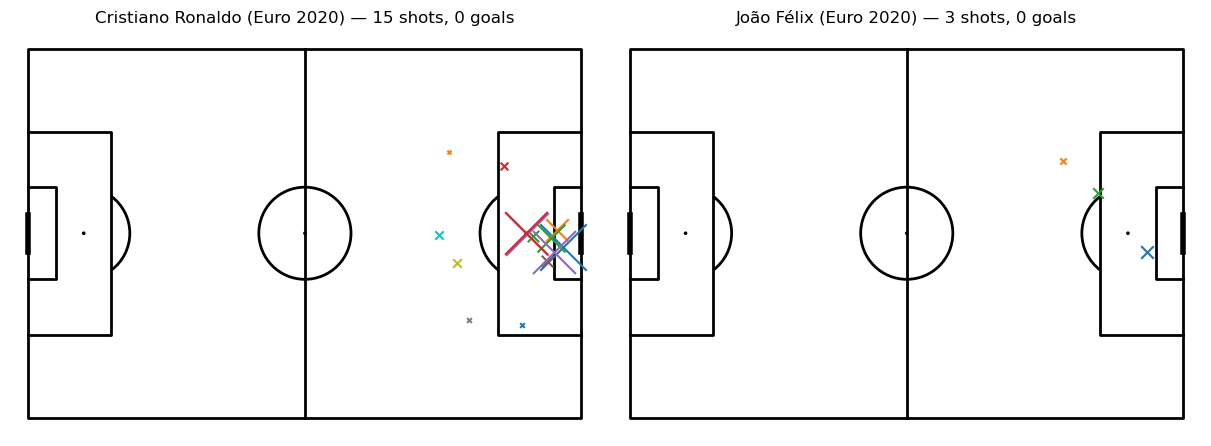

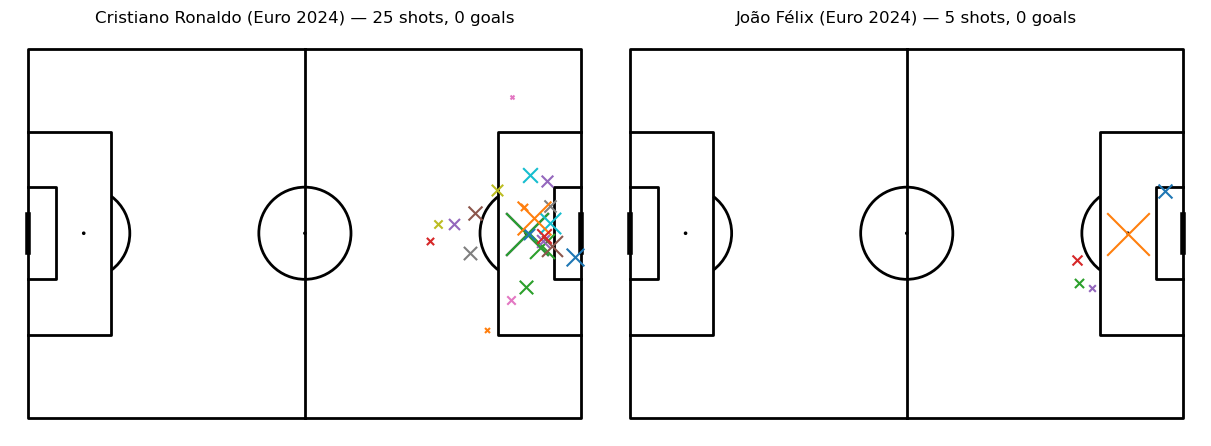

In [41]:
# ---------- Run for both tournaments ----------
# Euro 2020
df_match_20 = parser.match(55, 43)
mids_20 = df_match_20["match_id"].astype(int).tolist()
shots_20, players_20 = collect_tournament_shots_and_minutes(mids_20)

# Euro 2024
df_match_24 = parser.match(55, 282)
mids_24 = df_match_24["match_id"].astype(int).tolist()
shots_24, players_24 = collect_tournament_shots_and_minutes(mids_24)

# ---------- Ronaldo vs Félix table ----------
def pick_one(players_df, name, season):
    mask = players_df["player_name"].astype(str).str.contains(name, case=False, na=False)
    if not mask.any():
        return {"player": name, "season": season, "minutes": 0.0,
                "shots_per90": np.nan, "xg_per90": np.nan, "goals_per90": np.nan}
    r = players_df.loc[mask].sort_values("minutes", ascending=False).iloc[0]
    return {"player": name, "season": season,
            "minutes": float(r["minutes"]),
            "shots_per90": float(r["shots_per90"]),
            "xg_per90": float(r["xg_per90"]),
            "goals_per90": float(r["goals_per90"])}

rows = [
    pick_one(players_20, "Cristiano Ronaldo", "Euro 2020"),
    pick_one(players_20, "João Félix", "Euro 2020"),
    pick_one(players_24, "Cristiano Ronaldo", "Euro 2024"),
    pick_one(players_24, "João Félix", "Euro 2024"),
]
ron_felix_table = pd.DataFrame(rows)
print("Ronaldo vs Félix — per-90 table")
display(ron_felix_table)

# ---------- Diagnostics: confirm goal detection ----------
def diag(shots_df, who_contains, label):
    sdf = shots_df[shots_df["player_name"].astype(str).str.contains(who_contains, case=False, na=False)]
    print(f"\n{label}: shots = {len(sdf)}, goals found = {int((sdf['outcome_norm']=='goal').sum())}")
    # show what distinct outcome tokens we actually see
    print("Distinct outcome_norm values:", sdf["outcome_norm"].dropna().unique()[:10])

diag(shots_20, "Ronaldo", "Euro 2020 — Cristiano Ronaldo")
diag(shots_24, "Ronaldo", "Euro 2024 — Cristiano Ronaldo")

# ---------- (Optional) Make the two shot-map figures ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
plot_player_shotmap(axes[0], shots_20, "Cristiano Ronaldo", "Portugal", " (Euro 2020)")
plot_player_shotmap(axes[1], shots_20, "João Félix", "Portugal", " (Euro 2020)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
plot_player_shotmap(axes[0], shots_24, "Cristiano Ronaldo", "Portugal", " (Euro 2024)")
plot_player_shotmap(axes[1], shots_24, "João Félix", "Portugal", " (Euro 2024)")
plt.show()
